# Solución problema de multiplicación de cadenas de matrices

Librerías necesarias

In [20]:
import random
import time
import math
import matplotlib.pyplot as plt

# 1. Solución del problema

In [21]:
def matrixChainOrder(p):
    n = len(p) - 1
    m = [[0.0 for _ in range(n + 1)] for _ in range(n + 1)]
    s = [[0 for _ in range(n + 1)] for _ in range(n + 1)]
    for i in range(1, n + 1):
        m[i][i] = 0.0
    for l in range(2, n + 1):
        for i in range(1, n - l + 2):
            j = i + l - 1
            m[i][j] = float('inf')
            for k in range(i, j):
                q = m[i][k] + m[k + 1][j] + p[i - 1] * p[k] * p[j]
                if q < m[i][j]:
                    m[i][j] = q
                    s[i][j] = k
    return m, s

# 2. Análisis del algoritmo

## Idea general del análisis:  
Las instrucciones simples del algoritmo, como:
- asignaciones
- comparaciones
- accesos a arreglos
- sumas
- multiplicaciones
- returns  
tienen costo constante:
$$\Theta(1)$$
Por lo que el costo total queda dominado por:  
- los bucles anidados
- la cantidad de iteraciones de cada uno

## Análisis del algoritmo
### Primer bucle:
```
for l in range(2, n+1):
```
recorre las posibles longitudes de subcadenas.  
se ejecuta aproximadamente $n-1$ veces.

### Segundo bucle:
```
for i in range(1, n - l + 2):
```
recorre los posibles índices iniciales:  
El número de iteraciones es $n - l + 1$

### Tercer bucle:
```
for k in range(i, j):
```
Este bucle prueba todos los posibles puntos de división de la cadena.  
Como:  
$$j = i + l - 1$$
entonces:
$$j - i = l - 1$$
Por tanto, el ciclo sobre $k$ realiza $l - 1$ iteraciones.

### Operaciones internas
Las operaciones:
- accesos a tablas
- sumas
- multiplicaciones
- comparaciones
- asignaciones
son operaciones de costo constante:  
$$\Theta(1)$$

### Forma de la sumatoria
El tiempo total queda dado por:
$$T(n) = \sum_{l=2}^{n} \sum_{i=1}^{n-l+1} \sum_{k=i}^{j-1} 1$$
Como el ciclo interno ejecuta aproximadamente:
$$l-1$$
iteraciones:
$$T(n) = \sum_{l=2}^{n} \sum_{i=1}^{n-l+1} (l-1)$$
Y el segundo ciclo tiene:
$$n-l+1$$
iteraciones:
$$T(n) = \sum_{l=2}^{n} (n-l+1)(l-1)$$

### Expansión de la sumatoria
$$T(n) = \sum_{l=2}^{n} (n-l+1)(l-1)$$
Distribuyendo:
$$T(n) = \sum_{l=2}^{n} (nl-l^2+2l-n-1)$$
El término dominante es:
$$nl - l^2$$
cuya suma crece cúbicamente.  
Por propiedades de sumatorias:
$$\sum_{l=1}^{n} l = \Theta(n^2)$$
y
$$\sum_{l=1}^{n} l^2 = \Theta(n^3)$$
entonces
$$T(n) = \Theta(n^3)$$

### Complejidad final
La complejidad temporal del algoritmo es:
$$\Theta(n^3)$$

# 3. Comparación con diferentes tamaños de entrada

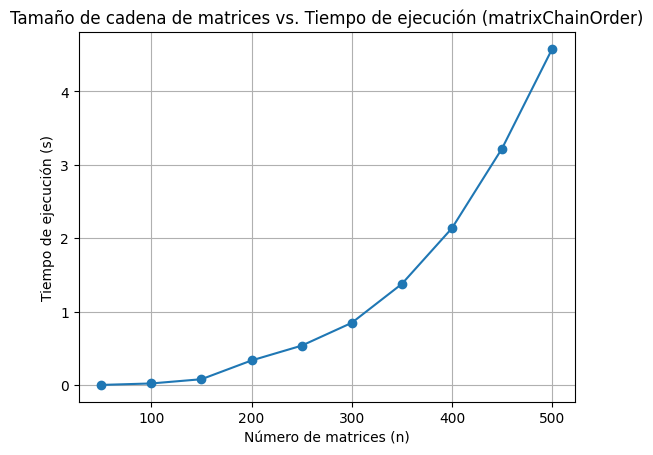

In [22]:
# Medición de tiempos para matrixChainOrder
tiempos = []
tamaños = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
random.seed(0)
for j in tamaños:
    p = [random.randint(5, 100) for _ in range(j + 1)]
    t0 = time.time()
    matrixChainOrder(p)
    t1 = time.time()
    tiempoFinal = t1 - t0
    tiempos.append(tiempoFinal)

plt.plot(tamaños, tiempos, marker='o')
plt.title("Tamaño de cadena de matrices vs. Tiempo de ejecución (matrixChainOrder)")
plt.xlabel("Número de matrices (n)")
plt.ylabel("Tiempo de ejecución (s)")
plt.grid()
plt.show()